# M1-T06: Spoilage-Sensitivity Column Verification

**Question.** Is `spoilage_sensitivity` a legitimate input feature, or is it leakage-prone and should it be kept out of the features?

| # | Requirement | Section |
|---|---|---|
| 1 | Correlation of `spoilage_sensitivity` with `was_spoiled` and `spoilage_risk` | 3 |
| 2 | Verdict recorded (legitimate input feature OR leakage-prone, secondary benchmark only) | 4, 5 and 6 |
| 3 | Decision documented in the EDA Report | 8 |
| 4 | M3-T08 (elasticity view) informed: does this column already cover part of it? | 7 |

Built on the earlier tasks: same data loading, same date parsing and the same stratified 80/20 split (seed 42) as M1-T04, so results here match the model-ready dataset.

*Note on the split:* the stratified random 80/20 split is used here only to stay comparable with M1-T04. The modelling tasks (M3-T01) use a split ordered by `transaction_date`, so this split should not be reused as the final train/test split.

## 1. Setup and load

In [ ]:
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

sns.set_theme(style="whitegrid"); warnings.filterwarnings("ignore")
RANDOM_STATE, TEST_SIZE = 42, 0.20
OUT_DIR = Path("processed"); FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(exist_ok=True); FIG_DIR.mkdir(exist_ok=True)

df = pd.read_csv("perishable_goods_management.csv")
if "day_of_week" not in df.columns:                       # same header repair as M1-T04
    df = df.rename(columns={[c for c in df.columns if str(c).startswith("Unnamed")][0]: "day_of_week"})
for c in ["transaction_date", "expiration_date"]:
    df[c] = pd.to_datetime(df[c], format="ISO8601", errors="raise")

# the exact split used in M1-T04
idx_train, idx_test = train_test_split(df.index, test_size=TEST_SIZE, stratify=df["was_spoiled"], random_state=RANDOM_STATE)
df["split"] = "train"; df.loc[idx_test, "split"] = "test"
df["remaining_ratio"] = (df["days_until_expiry"] / df["shelf_life_days"]).clip(0, 1)
# shape is 44 = the 42 original columns + 'split' and 'remaining_ratio' added above
print(df.shape, "|", df["split"].value_counts().to_dict(), "| missing values:", int(df.isna().sum().sum()))

(100000, 44) | {'train': 80000, 'test': 20000} | missing values: 0


## 2. What is this column?

In [2]:
s = df["spoilage_sensitivity"]
print(s.describe().round(3).to_string())
print("\ndistinct values:", sorted(s.unique()))

per_cat = df.groupby("category")["spoilage_sensitivity"].agg(["nunique", "min", "max"])
print("\nvalues per category:\n", per_cat.to_string())
per_prod = df.groupby("product_name")["spoilage_sensitivity"].nunique().max()
print("\nmax distinct values inside one category:", per_cat["nunique"].max(), "| inside one product_name:", per_prod)

count    100000.000
mean          0.686
std           0.215
min           0.300
25%           0.500
50%           0.750
75%           0.900
max           0.950

distinct values: [np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.75), np.float64(0.85), np.float64(0.9), np.float64(0.95)]

values per category:
                  nunique   min   max
category                            
Bakery                 1  0.50  0.50
Beverages              1  0.40  0.40
Dairy                  1  0.70  0.70
Deli                   1  0.75  0.75
Frozen_Meals           1  0.30  0.30
Meat                   1  0.90  0.90
Pharmaceuticals        1  0.85  0.85
Produce                1  0.60  0.60
Ready_to_Eat           1  0.90  0.90
Seafood                1  0.95  0.95

max distinct values inside one category: 1 | inside one product_name: 1


**Reading.** The column has only 9 distinct values and every category has exactly one of them (Meat and Ready_to_Eat share 0.90). So it is a **fixed category-level attribute**, not something measured per batch. It cannot carry any information about what happened to an individual batch, and it is known before the sale.

## 3. Correlation with `was_spoiled` and `spoilage_risk`

In [3]:
def boot_ci(x, y, n=300, seed=0, method="pearson"):
    rng = np.random.default_rng(seed); vals = []
    for _ in range(n):
        i = rng.integers(0, len(x), len(x))
        vals.append(pd.Series(x[i]).corr(pd.Series(y[i]), method=method))
    return np.percentile(vals, [2.5, 97.5])

x = df["spoilage_sensitivity"].to_numpy()
rows = []
for target in ["was_spoiled", "spoilage_risk"]:
    y = df[target].to_numpy()
    r_p, p_p = stats.pearsonr(x, y); r_s, _ = stats.spearmanr(x, y)
    lo, hi = boot_ci(x, y)
    rows.append([target, r_p, lo, hi, r_s, p_p])
corr_tbl = pd.DataFrame(rows, columns=["with", "pearson_r", "ci95_low", "ci95_high", "spearman_rho", "p_value"]).set_index("with")
print(corr_tbl.round(4).to_string())
print("\nR^2 (share of variance explained):", {t: round(corr_tbl.loc[t, 'pearson_r'] ** 2, 4) for t in corr_tbl.index})

               pearson_r  ci95_low  ci95_high  spearman_rho  p_value
with                                                                
was_spoiled       0.0370    0.0309     0.0433        0.0367      0.0
spoilage_risk     0.2537    0.2482     0.2588        0.2347      0.0

R^2 (share of variance explained): {'was_spoiled': np.float64(0.0014), 'spoilage_risk': np.float64(0.0643)}


                      with_was_spoiled  with_spoilage_risk
packaging_score                 -0.088              -0.675
handling_score                  -0.056              -0.394
temp_deviation                   0.043               0.332
spoilage_sensitivity             0.037               0.254
distribution_hours               0.029               0.269
temp_abuse_events                0.029               0.190
remaining_ratio                 -0.028              -0.218
daily_demand                     0.023               0.145
base_price                       0.011               0.065
storage_temp                     0.009               0.046
demand_variability               0.005               0.007
supplier_score                   0.003              -0.000
shelf_life_days                 -0.002              -0.014


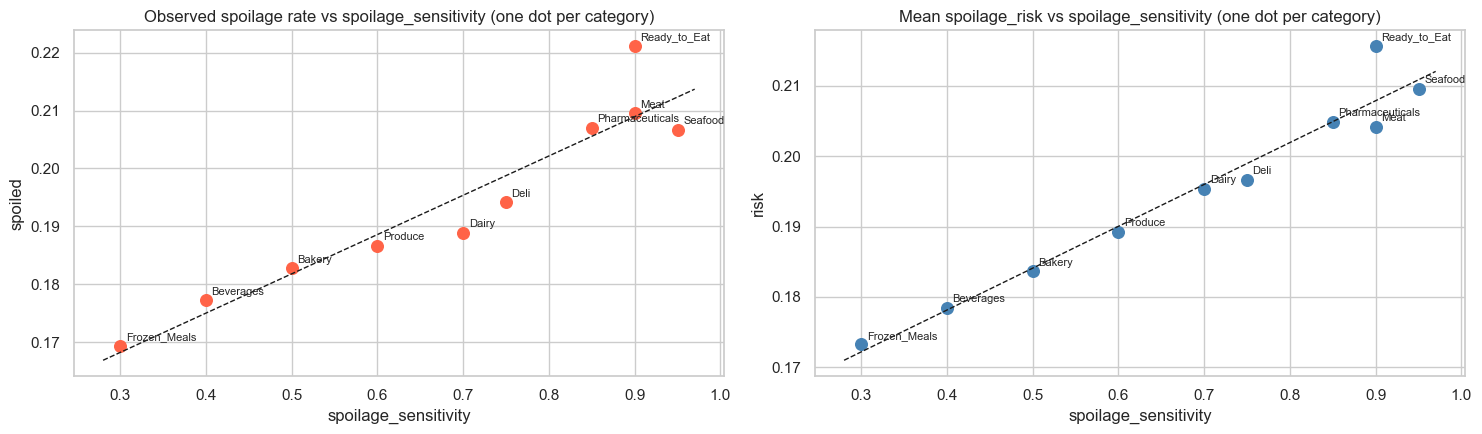

Category-level spread of spoilage rate: 16.9% to 22.1% (overall 19.4%)


In [4]:
# put the number in context: how do the other pre-sale inputs correlate with was_spoiled and spoilage_risk?
inputs = ["spoilage_sensitivity", "shelf_life_days", "remaining_ratio", "storage_temp", "temp_deviation", "temp_abuse_events",
          "distribution_hours", "handling_score", "packaging_score", "supplier_score", "base_price", "daily_demand", "demand_variability"]
ctx = pd.DataFrame({"with_was_spoiled": df[inputs].corrwith(df["was_spoiled"]),
                    "with_spoilage_risk": df[inputs].corrwith(df["spoilage_risk"])})
ctx = ctx.reindex(ctx["with_was_spoiled"].abs().sort_values(ascending=False).index)
print(ctx.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
g = df.groupby("category").agg(sens=("spoilage_sensitivity", "first"), spoiled=("was_spoiled", "mean"), risk=("spoilage_risk", "mean")).sort_values("sens")
for ax, col, color, ttl in [(axes[0], "spoiled", "tomato", "Observed spoilage rate"), (axes[1], "risk", "steelblue", "Mean spoilage_risk")]:
    ax.scatter(g["sens"], g[col], s=70, color=color)
    for name, r in g.iterrows(): ax.annotate(name, (r["sens"], r[col]), fontsize=8, xytext=(4, 4), textcoords="offset points")
    k = np.polyfit(g["sens"], g[col], 1); xs = np.linspace(0.28, 0.97, 10); ax.plot(xs, np.polyval(k, xs), "k--", lw=1)
    ax.set(title=f"{ttl} vs spoilage_sensitivity (one dot per category)", xlabel="spoilage_sensitivity", ylabel=col)
plt.tight_layout(); plt.savefig(FIG_DIR / "t06_01_sensitivity_vs_spoilage.png", dpi=150, bbox_inches="tight"); plt.show()
print("Category-level spread of spoilage rate: %.1f%% to %.1f%% (overall %.1f%%)" % (100*g.spoiled.min(), 100*g.spoiled.max(), 100*df.was_spoiled.mean()))

**Reading.** The link with `was_spoiled` is real but very weak (r about 0.04, so it explains roughly 0.1% of the variance). The link with `spoilage_risk` is clearly stronger (about 0.25), which shows `spoilage_risk` is partly built from the sensitivity. Across categories the spoilage rate rises with sensitivity, but only from about 17% to 22%.

## 4. Leakage tests

Leakage means a feature either (a) is not known at the moment of prediction, (b) is computed from the target or from things that happen after it, or (c) predicts the target far better than any honest input could. The column is checked against all three.

In [5]:
# (a) and (b): structure
is_static   = df.groupby("category")["spoilage_sensitivity"].nunique().max() == 1
# is it just a relabelled category? how much of its variance is explained by category alone
eta2 = 1 - df.groupby("category")["spoilage_sensitivity"].var(ddof=0).mul(df.groupby("category").size()).sum() / (df["spoilage_sensitivity"].var(ddof=0) * len(df))
print(f"(a/b) constant inside every category: {is_static}")
print(f"      share of its variance explained by category: {eta2:.1%}  -> it is a lookup table on category")

# (c) strength: leaks usually show near-perfect separation
tr, te = df[df.split == "train"], df[df.split == "test"]
auc_sens = roc_auc_score(te["was_spoiled"], te["spoilage_sensitivity"])
auc_risk = roc_auc_score(te["was_spoiled"], te["spoilage_risk"])
auc_cat  = roc_auc_score(te["was_spoiled"], te["category"].map(tr.groupby("category")["was_spoiled"].mean()))
print(f"(c)   single-column test AUC for was_spoiled:  spoilage_sensitivity {auc_sens:.3f} | category rate {auc_cat:.3f} | spoilage_risk {auc_risk:.3f}  (0.5 = no signal, 1.0 = perfect)")

(a/b) constant inside every category: True
      share of its variance explained by category: 100.0%  -> it is a lookup table on category
(c)   single-column test AUC for was_spoiled:  spoilage_sensitivity 0.530 | category rate 0.528 | spoilage_risk 0.586  (0.5 = no signal, 1.0 = perfect)


### 4.1 Ablation: does the column add anything on a real model?

Gradient-boosting classifiers are trained on the train rows and scored on the test rows. Honest inputs only: no outcome columns, no `spoilage_risk`. Five versions, changing only the sensitivity and category columns.

In [6]:
base_inputs = ["shelf_life_days", "remaining_ratio", "storage_temp", "temp_deviation", "temp_abuse_events", "distribution_hours",
               "handling_score", "packaging_score", "supplier_score", "base_price", "initial_quantity", "daily_demand",
               "demand_variability", "is_weekend", "month", "markdown_applied", "is_promoted"]
df["category_code"] = df["category"].astype("category").cat.codes
sets = {
    "A. base inputs only":                     base_inputs,
    "B. base + category":                      base_inputs + ["category_code"],
    "C. base + spoilage_sensitivity":          base_inputs + ["spoilage_sensitivity"],
    "D. base + category + sensitivity":        base_inputs + ["category_code", "spoilage_sensitivity"],
    "E. base + spoilage_risk (benchmark)":     base_inputs + ["spoilage_risk"],
}
res = []
for name, cols in sets.items():
    aucs = []
    for seed in range(3):
        m = HistGradientBoostingClassifier(max_depth=4, learning_rate=0.06, max_iter=200, random_state=seed).fit(df.loc[df.split == "train", cols], tr["was_spoiled"])
        aucs.append(roc_auc_score(te["was_spoiled"], m.predict_proba(df.loc[df.split == "test", cols])[:, 1]))
    res.append([name, np.mean(aucs), np.std(aucs)])
abl = pd.DataFrame(res, columns=["feature set", "test_AUC", "std_over_3_seeds"]).set_index("feature set")
print(abl.round(4).to_string())

gain_sens = abl.loc["D. base + category + sensitivity", "test_AUC"] - abl.loc["B. base + category", "test_AUC"]
gain_sens_alone = abl.loc["C. base + spoilage_sensitivity", "test_AUC"] - abl.loc["A. base inputs only", "test_AUC"]
print(f"\nAUC change from adding sensitivity on top of category : {gain_sens:+.4f}")
print(f"AUC change from adding sensitivity to the base inputs : {gain_sens_alone:+.4f}")

                                     test_AUC  std_over_3_seeds
feature set                                                    
A. base inputs only                    0.5805            0.0012
B. base + category                     0.5801            0.0003
C. base + spoilage_sensitivity         0.5808            0.0002
D. base + category + sensitivity       0.5806            0.0002
E. base + spoilage_risk (benchmark)    0.5841            0.0001

AUC change from adding sensitivity on top of category : +0.0005
AUC change from adding sensitivity to the base inputs : +0.0003


In [7]:
# how the column relates to spoilage_risk: is it an ingredient of that score?
core = [c for c in base_inputs if c not in ("is_weekend", "month", "markdown_applied", "is_promoted", "initial_quantity")]
r2_without = LinearRegression().fit(df[core], df["spoilage_risk"]).score(df[core], df["spoilage_risk"])
r2_with    = LinearRegression().fit(df[core + ["spoilage_sensitivity"]], df["spoilage_risk"]).score(df[core + ["spoilage_sensitivity"]], df["spoilage_risk"])
print(f"R^2 of spoilage_risk explained by the other inputs : {r2_without:.3f}")
print(f"R^2 after adding spoilage_sensitivity               : {r2_with:.3f}   (+{r2_with - r2_without:.3f})")

# does was_spoiled behave like a draw from spoilage_risk? (calibration)
bins = pd.cut(df["spoilage_risk"], [0, .1, .15, .2, .25, .3, .5], include_lowest=True)
cal = df.groupby(bins, observed=True).agg(mean_risk=("spoilage_risk", "mean"), spoiled_rate=("was_spoiled", "mean"), rows=("was_spoiled", "size"))
print("\nspoilage_risk vs observed spoilage rate:\n", cal.round(3).to_string())

R^2 of spoilage_risk explained by the other inputs : 0.855
R^2 after adding spoilage_sensitivity               : 0.885   (+0.030)

spoilage_risk vs observed spoilage rate:
                mean_risk  spoiled_rate   rows
spoilage_risk                                
(-0.001, 0.1]      0.089         0.087   2089
(0.1, 0.15]        0.131         0.129  17654
(0.15, 0.2]        0.176         0.173  35395
(0.2, 0.25]        0.223         0.225  31200
(0.25, 0.3]        0.269         0.271  11405
(0.3, 0.5]         0.327         0.329   2257


**Reading.**

* **Pre-sale and static:** it is a per-category constant, so it is available before any batch is sold and cannot be computed from the target or from outcomes.
* **Not built from outcomes:** the values are round numbers (0.30, 0.40 ... 0.95) shared by whole categories, which points to a hand-assigned attribute. It does correlate with category-level spoilage rates, as a legitimate pre-sale attribute should; only an exact rescaling of those rates would be a warning sign (see the informational line in Section 6).
* **Weak, not suspicious:** a single-column AUC of about 0.53 is almost the same as using the category alone. A leak would show near-perfect separation.
* **Adds nothing on top of `category`:** the ablation shows no meaningful AUC change when it is added to a model that already has `category`, which is expected because it is a function of category.
* **Low ceiling for everyone:** all AUCs are around 0.58 because `was_spoiled` behaves like a random draw from `spoilage_risk` (the calibration table shows observed rates match the risk almost exactly). Even the pre-computed risk score only reaches about 0.59, so a weak signal from this column is expected, not a sign that something is hidden.
* **It is an ingredient of `spoilage_risk`:** that is a modelling relationship, not target leakage. `spoilage_risk` is the one that stays reserved, because it is a pre-computed score that carries much more of the spoilage signal (AUC about 0.59) and is already tracked as a benchmark.

## 5. Redundancy with `category` (the practical cost of keeping it)

In [8]:
cat_dummies = pd.get_dummies(df["category"], dtype=float)
r2_cat = LinearRegression().fit(cat_dummies, df["spoilage_sensitivity"]).score(cat_dummies, df["spoilage_sensitivity"])
print(f"R^2 of spoilage_sensitivity predicted from the category one-hot columns: {r2_cat:.4f}")
print(f"-> the one-hot `category` block already holds {r2_cat:.1%} of this column's information.")
print("Only difference: it puts the 10 categories on one ordered scale (0.30 Frozen_Meals ... 0.95 Seafood),")
print("which is a compact, interpretable summary and lets linear models use 'how perishable' as one number.")

R^2 of spoilage_sensitivity predicted from the category one-hot columns: 1.0000
-> the one-hot `category` block already holds 100.0% of this column's information.
Only difference: it puts the 10 categories on one ordered scale (0.30 Frozen_Meals ... 0.95 Seafood),
which is a compact, interpretable summary and lets linear models use 'how perishable' as one number.


## 6. Verdict

In [9]:
# The "derived from outcomes" question is not a gating flag: the column is constant inside every category, so it cannot be computed from any single batch's outcome.
# Informational check only: a legitimate pre-sale attribute is EXPECTED to correlate with category spoilage rates; an exact rescaling (r near 1.00) would be the warning sign.
r_cat = stats.pearsonr(g["sens"], g["spoiled"])[0]
leak_flags = {
    "not a fixed pre-sale attribute (varies per batch)": bool(not is_static),
    "near-perfect single-column separation (AUC>0.9)": bool(auc_sens > 0.9),
    "|corr| with was_spoiled above 0.5":               bool(abs(corr_tbl.loc["was_spoiled", "pearson_r"]) > 0.5),
    "ablation AUC jump above 0.01":                    bool(abs(gain_sens) > 0.01),
}
for k, v in leak_flags.items(): print(f"{'FLAGGED' if v else 'ok     '}  {k}")
print(f"\n(info) category-level correlation of sensitivity with observed spoilage rate: r = {r_cat:.2f}  (only an exact rescaling, r near 1.00, would be a warning sign)")
VERDICT = "LEGITIMATE input feature (keep)" if not any(leak_flags.values()) else "LEAKAGE-PRONE (exclude; secondary benchmark only)"
print("\nVERDICT:", VERDICT)

ok       not a fixed pre-sale attribute (varies per batch)
ok       near-perfect single-column separation (AUC>0.9)
ok       |corr| with was_spoiled above 0.5
ok       ablation AUC jump above 0.01

(info) category-level correlation of sensitivity with observed spoilage rate: r = 0.94  (only an exact rescaling, r near 1.00, would be a warning sign)

VERDICT: LEGITIMATE input feature (keep)


**Decision.** `spoilage_sensitivity` is a **legitimate input feature**. It is a static, pre-sale property of the category, it is not derived from the target, and its link with `was_spoiled` is weak (r about 0.04). It stays in the feature matrix produced by M1-T04, where it is already a scaled numeric column, so **no change to the model-ready dataset is needed**.

Two notes for the modelling tasks:

1. **It is redundant with `category`.** Tree models are not affected. For an unregularised linear model the one-hot `category` block and this column are perfectly collinear, so use regularisation or drop one of the two there.
2. **It is not a stand-in for `spoilage_risk`.** `spoilage_risk` remains reserved (never an input to Track 3A or Track 3B; kept only as an evaluation benchmark), as set in M1-T01 and M1-T04.

## 7. Input for M3-T08 (elasticity view)

Price elasticity asks how much demand (units sold) changes when the price or discount changes. Does `spoilage_sensitivity` already cover part of that? Because the column has one value per category, the only possible link is **between categories**. Here each category gets three simple descriptors, then they are compared with the sensitivity (10 points only, so this is descriptive, not a test).

                 sensitivity  markdown_rate  avg_discount_when_marked_down  sell_through_no_markdown  sell_through_markdown  discount_slope_on_sell_through
category                                                                                                                                                   
Frozen_Meals            0.30          0.142                          0.199                     0.495                  0.529                           0.191
Beverages               0.40          0.154                          0.201                     0.786                  0.834                           0.249
Bakery                  0.50          0.478                          0.373                     0.866                  0.825                           0.004
Produce                 0.60          0.240                          0.261                     0.819                  0.803                          -0.056
Dairy                   0.70          0.171                     

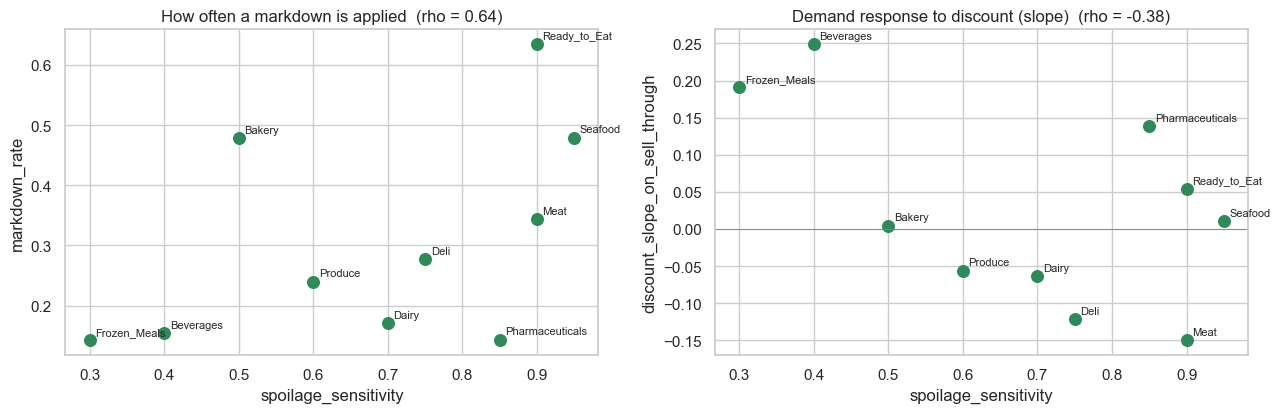

In [10]:
df["sell_through"] = df["units_sold"] / df["initial_quantity"]
rows = []
for c, gp in df.groupby("category"):
    md = gp[gp.markdown_applied == 1]; nomd = gp[gp.markdown_applied == 0]
    rows.append({"category": c, "sensitivity": gp["spoilage_sensitivity"].iloc[0],
                 "markdown_rate": gp["markdown_applied"].mean(),
                 "avg_discount_when_marked_down": md["discount_pct"].mean(),
                 "sell_through_no_markdown": nomd["sell_through"].mean(),
                 "sell_through_markdown": md["sell_through"].mean(),
                 "discount_slope_on_sell_through": np.polyfit(gp["discount_pct"], gp["sell_through"], 1)[0]})
el = pd.DataFrame(rows).set_index("category").sort_values("sensitivity")
print(el.round(3).to_string())
rho = el.drop(columns="sensitivity").apply(lambda c: stats.spearmanr(el["sensitivity"], c)[0])
print("\nSpearman rho with spoilage_sensitivity (n = 10 categories):\n", rho.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
for ax, col, ttl in [(axes[0], "markdown_rate", "How often a markdown is applied"),
                     (axes[1], "discount_slope_on_sell_through", "Demand response to discount (slope)")]:
    ax.scatter(el["sensitivity"], el[col], s=70, color="seagreen")
    for n, r in el.iterrows(): ax.annotate(n, (r["sensitivity"], r[col]), fontsize=8, xytext=(4, 4), textcoords="offset points")
    ax.axhline(0, color="grey", lw=0.6) if col.endswith("slope_on_sell_through") else None
    ax.set(title=ttl + f"  (rho = {rho[col]:.2f})", xlabel="spoilage_sensitivity", ylabel=col)
plt.tight_layout(); plt.savefig(FIG_DIR / "t06_02_sensitivity_vs_pricing_behaviour.png", dpi=150, bbox_inches="tight"); plt.show()

**Reading for M3-T08.**

* There is a **weak-to-moderate, descriptive pattern**: higher-sensitivity categories tend to be marked down more often and more deeply (rho about 0.64 with markdown rate and 0.56 with markdown depth). With only 10 categories this is not a test, and the pattern is not monotonic (for example Pharmaceuticals, at 0.85, has one of the lowest markdown rates). The column may still be useful as a *segment* or *moderator* of pricing behaviour, but this should not be read as a finding.
* It does **not** measure how demand reacts to price. The discount slope on sell-through has no clear relation with it (rho about -0.4, with 10 points, and the slopes themselves are small and change sign across categories), and the column is constant within a category, so it cannot explain any variation inside a category.
* **Recommendation:** the column covers **none of the elasticity estimate itself**. M3-T08 should estimate elasticity from price/discount against demand, within category, and may use `spoilage_sensitivity` only as a category-level grouping or an interaction term (for example, "do more perishable categories respond differently to markdowns?").

## 8. Text for the EDA Report (Task 5) and saved files

In [12]:
r_sp, r_rk = corr_tbl.loc["was_spoiled", "pearson_r"], corr_tbl.loc["spoilage_risk", "pearson_r"]
text = f"""
**Spoilage-Sensitivity Column Verification (M1-T06)**

**What it is.** `spoilage_sensitivity` takes {s.nunique()} distinct values ({s.min():.2f} to {s.max():.2f}) and is constant inside every
category (Frozen_Meals 0.30 ... Seafood 0.95; Meat and Ready_to_Eat both 0.90). It is a fixed, pre-sale property of the category, not a per-batch measurement.

**Correlations.** With `was_spoiled`: r = {r_sp:.3f} (95% CI {corr_tbl.loc['was_spoiled','ci95_low']:.3f} to {corr_tbl.loc['was_spoiled','ci95_high']:.3f}), explaining about {100*r_sp**2:.1f}% of the variance.
With `spoilage_risk`: r = {r_rk:.3f}. The column is an ingredient of `spoilage_risk` (adding it raises the R^2 of the risk score from {r2_without:.2f} to {r2_with:.2f}).

**Leakage tests.** Known before the sale and not derived from the target. Single-column test AUC {auc_sens:.3f} (category alone {auc_cat:.3f}, `spoilage_risk` {auc_risk:.3f}).
Adding it to a gradient-boosting model that already has `category` changes test AUC by {gain_sens:+.4f}, i.e. nothing.

**Verdict: {VERDICT}.** It stays a feature in the M1-T04 model-ready dataset (no change). It is {r2_cat:.0%} explained by the `category` one-hot columns, so unregularised linear models should
drop one of the two. `spoilage_risk` remains reserved as an evaluation benchmark only (not an input to either track).

**For M3-T08 (elasticity).** Across the 10 categories the column shows a descriptive association (10 categories only, not a test) with markdown frequency (rho {rho['markdown_rate']:.2f}) and depth (rho {rho['avg_discount_when_marked_down']:.2f}) but no clear
relation with demand response to discount (rho {rho['discount_slope_on_sell_through']:.2f}); it is constant within a category. It covers none of the elasticity estimate and should
be used only as a category-level segment or interaction term.
"""
print(text)
(OUT_DIR / "m1_t06_report_text.md").write_text(text.strip() + "\n", encoding="utf-8")
(OUT_DIR / "m1_t06_verdict.json").write_text(json.dumps({
    "task": "M1-T06", "column": "spoilage_sensitivity", "verdict": VERDICT,
    "distinct_values": int(s.nunique()), "constant_within_category": bool(is_static),
    "pearson_with_was_spoiled": round(float(r_sp), 4), "pearson_with_spoilage_risk": round(float(r_rk), 4),
    "single_column_auc": round(float(auc_sens), 4), "auc_gain_on_top_of_category": round(float(gain_sens), 4),
    "r2_explained_by_category_onehot": round(float(r2_cat), 4),
    "leakage_flags": leak_flags, "action": "keep as feature; no change to model_ready_dataset; spoilage_risk stays reserved",
    "elasticity_note": "no demand-response information; use only as category-level segment/interaction in M3-T08"}, indent=2))
print("saved:", sorted(p.name for p in OUT_DIR.glob("m1_t06*")))


**Spoilage-Sensitivity Column Verification (M1-T06)**

**What it is.** `spoilage_sensitivity` takes 9 distinct values (0.30 to 0.95) and is constant inside every
category (Frozen_Meals 0.30 ... Seafood 0.95; Meat and Ready_to_Eat both 0.90). It is a fixed, pre-sale property of the category, not a per-batch measurement.

**Correlations.** With `was_spoiled`: r = 0.037 (95% CI 0.031 to 0.043), explaining about 0.1% of the variance.
With `spoilage_risk`: r = 0.254. The column is an ingredient of `spoilage_risk` (adding it raises the R^2 of the risk score from 0.85 to 0.88).

**Leakage tests.** Known before the sale and not derived from the target. Single-column test AUC 0.530 (category alone 0.528, `spoilage_risk` 0.586).
Adding it to a gradient-boosting model that already has `category` changes test AUC by +0.0005, i.e. nothing.

**Verdict: LEGITIMATE input feature (keep).** It stays a feature in the M1-T04 model-ready dataset (no change). It is 100% explained by the `category` one-hot 